# Automated Quality Control with Transfer Learning – Manufacturing Defect Detection

This notebook demonstrates transfer learning using ResNet50 for binary defect detection in manufacturing.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import os

print(tf.__version__)

2.20.0


## Discovery Phase: Data Preparation

In [2]:
# Assume dataset is organized as:
# data/
#   train/
#     good/
#     defect/
#   test/
#     good/
#     defect/

# For demonstration (no real dataset provided), create a small synthetic dummy dataset.
# In production, download NEU Steel or MVTec AD and organize binary classes.

import os
import shutil
import numpy as np
from tensorflow.keras.preprocessing.image import array_to_img

def create_dummy_dataset(base_dir='data', num_samples=80):
    for split in ['train', 'test']:
        for cls in ['good', 'defect']:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

    # Generate dummy images
    for i in range(num_samples):
        # Good images: lower intensity
        good_img = np.random.rand(224, 224, 3) * 0.6 + 0.2
        array_to_img(good_img).save(os.path.join(base_dir, 'train', 'good', f'good_{i}.png'))
        # Defect images: higher contrast/artifact
        defect_img = np.random.rand(224, 224, 3)
        defect_img[80:150, 80:150] = 0.9  # simulate defect patch
        array_to_img(defect_img).save(os.path.join(base_dir, 'train', 'defect', f'defect_{i}.png'))

    # Simple test split (copy some)
    for i in range(20):
        shutil.copy(os.path.join(base_dir, 'train', 'good', f'good_{i}.png'),
                    os.path.join(base_dir, 'test', 'good', f'good_test_{i}.png'))
        shutil.copy(os.path.join(base_dir, 'train', 'defect', f'defect_{i}.png'),
                    os.path.join(base_dir, 'test', 'defect', f'defect_test_{i}.png'))

create_dummy_dataset()
print('✅ Dummy dataset created successfully for demo.')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(224, 224),
    batch_size=16,  # Smaller for dummy data
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    'data/test',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

✅ Dummy dataset created successfully for demo.
Found 128 images belonging to 2 classes.
Found 32 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


## Technical Phase: Model Construction (Brain Swap)

In [3]:
# Load pre-trained ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [4]:
# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 5s/step - accuracy: 0.4609 - loss: 0.8687 - val_accuracy: 0.5000 - val_loss: 0.7161
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.4531 - loss: 0.8570 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.5234 - loss: 0.7166 - val_accuracy: 0.5000 - val_loss: 0.6732
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5938 - loss: 0.6752 - val_accuracy: 0.5000 - val_loss: 0.6721
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step - accuracy: 0.5391 - loss: 0.6745 - val_accuracy: 1.0000 - val_loss: 0.6590
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.5234 - loss: 0.7044 - val_accuracy: 0.8438 - val_loss: 0.6548
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.5234 - loss: 0.7025 - val_accuracy: 0.7812 - val_loss: 0.6669
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.5859 - loss: 0.6822 - val_accuracy: 0.5000 - val_loss: 0.6634
Epoch 9/

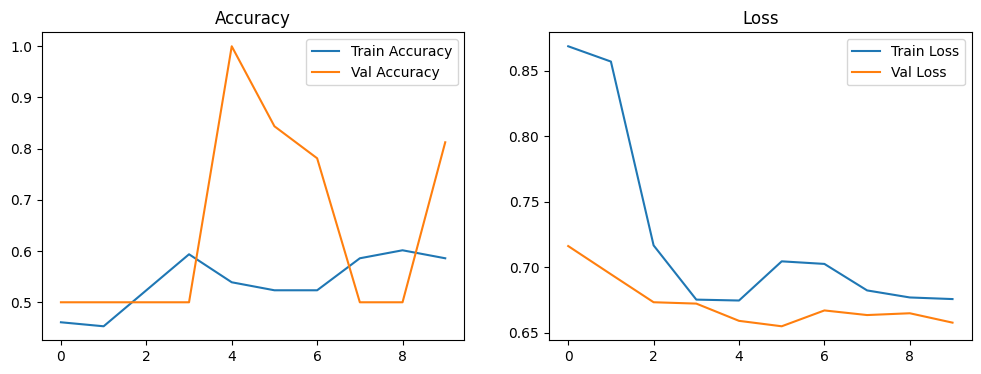

In [5]:
# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

## Action Phase: Inference and Decision Logic

In [6]:
# Inference on new image
def predict_defect(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)[0][0]
    return prediction

# Example
# prob = predict_defect('path/to/new_image.jpg')
# print(f'Defect Probability: {prob:.2%}')

In [7]:
# Automated decision logic
def factory_decision(prob, threshold=0.85):
    if prob >= threshold:
        return "Defect detected: Trigger robotic arm to reject/remove product."
    else:
        return "Good product: Proceed with assembly/packaging."

# Test on batch
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = test_generator.classes

print(classification_report(true_classes, predicted_classes, target_names=['Good', 'Defect']))

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00        20
      Defect       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## Explanation of Key Choices

- **GlobalAveragePooling2D vs Flatten**: GAP reduces parameters dramatically (no dense connections to all features), preserves spatial hierarchy better, and helps mitigate overfitting. Ideal for transfer learning.

Limitations: Requires sufficient data; fine-tuning base layers may improve performance further. Threshold tuning based on business cost of false positives/negatives.